# WattWise: Exact Method (Dynamic Programming) for Battery Dispatch

Minimise a household's daily electricity bill under CEB's Time-of-Use tariff by deciding how much
to charge or discharge the battery in every 30-minute slot. This notebook presents the **exact
method**: backward-induction Dynamic Programming, and its comparison with the Genetic Algorithm.

The solver code lives in `src/` (tested with `pytest`); this notebook imports it:

| file | contents |
|---|---|
| `src/model.py` | shared problem: data, parameters, `simulate()` (bill + constraint check) |
| `src/dp_solver.py` | the DP (this notebook) |
| `src/heuristic_solver.py` | the GA (see `heuristic_energy_optimization.ipynb`) |
| `src/compare.py` | experiments behind the result tables (writes `results/*.csv`) |
| `scripts/calibrate_eta.py` | battery efficiency calibration from the raw 5-minute logs |


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import model
from dp_solver import solve_dp, step_limits, DEFAULT_DELTA

RESULTS, FIGURES = ROOT / "results", ROOT / "figures"
FIGURES.mkdir(exist_ok=True)
df = model.load_profiles()
print("days:", model.list_days(df))
print(f"eta_c = eta_d = {model.ETA_C}, reserve = {model.SOC_RESERVE_FRAC}, "
      f"rate <= {model.MAX_CHARGE_KWH} / {model.MAX_DISCHARGE_KWH} kWh per slot, DP grid step = {DEFAULT_DELTA} kWh")

days: ['2026-09-10', '2026-09-11', '2026-09-13', '2026-09-16', '2026-09-17']
eta_c = eta_d = 0.91, reserve = 0.2, rate <= 1.1 / 1.25 kWh per slot, DP grid step = 0.001 kWh


## 1. Formulation (as implemented)

Slots $t = 0..T-1$ ($\Delta t$ = 0.5 h), load $d_t$, solar $g_t$, price $p_t$ (kWh per slot).
Decision $a_t$ = battery energy on the house side ($>0$ discharge, $<0$ charge).

$$\min_{a} \sum_t p_t \, \max(0,\; d_t - g_t - a_t)$$

subject to
* rate: $-R_c\Delta t \le a_t \le R_d \Delta t$ (1.10 / 1.25 kWh)
* no export: $a_t \le \max(0, d_t - g_t)$, surplus solar is curtailed
* SoC: $0.2C \le SoC_t \le C$, with $SoC_{t+1} = SoC_t - a_t/\eta_d$ (discharge) or $SoC_t + |a_t|\eta_c$ (charge)
* every day starts at the floor $SoC_0 = 0.2C$; leftover energy at the end is worth nothing.

### DP
* **Stage** $t$, **state** $i$ = SoC grid level $SoC_i = 0.2C + i\delta$.
* **Action** $k$ = number of grid steps moved ($k>0$ discharge). The next state $j=i-k$ is always on the
  grid, so no rounding or interpolation is needed; the house-side energy is backed out of the move:
  $a = k\delta\eta_d$ (discharge) or $a = k\delta/\eta_c$ (charge, negative).
* **Bellman:** $V_T(i)=0$, $\;V_t(i) = \min_k \big[\, p_t\max(0, d_t-g_t-a(k)) + V_{t+1}(i-k) \,\big]$ over feasible $k$.
* Solved backward in $O(T \cdot N_{states} \cdot N_{moves})$; the optimal schedule is recovered by a
  forward pass through the policy table.

## 2. Validation on the hand example

1-unit battery, three slots (off-peak 33, day 47, peak 106), 1 kWh load at peak only, $\eta = 1$,
no reserve, start empty. Doing nothing costs **106**; the optimum is **33** (charge off-peak, hold,
discharge at peak). Computed by hand first, then checked against the code (also in `tests/`).

In [2]:
hand = {"solar": np.zeros(3), "demand": np.array([0, 0, 1.0]), "price": np.array([33, 47, 106.0])}
hand_params = dict(eta_c=1.0, eta_d=1.0, max_charge=1.0, max_discharge=1.0, reserve_frac=0.0)

for delta in (1.0, 0.5):
    r = solve_dp(hand, capacity=1, delta=delta, **hand_params)
    print(f"delta = {delta}:  optimal bill = {r['bill']:.0f}  schedule = {r['schedule']}  (do nothing = {model.baseline_bill(hand):.0f})")

r = solve_dp(hand, capacity=1, delta=1.0, **hand_params)
print("\nValue table V_t(s):")
print(pd.DataFrame(r["V"], index=["t=1 off-peak", "t=2 day", "t=3 peak", "end"], columns=["s=0", "s=1"]))
print("\nPolicy (steps: -1 charge, 0 hold, +1 discharge):")
print(pd.DataFrame(r["K"], index=["t=1", "t=2", "t=3"], columns=["s=0", "s=1"]))

delta = 1.0:  optimal bill = 33  schedule = [-1.  0.  1.]  (do nothing = 106)
delta = 0.5:  optimal bill = 33  schedule = [-1.  0.  1.]  (do nothing = 106)

Value table V_t(s):
                s=0  s=1
t=1 off-peak   33.0  0.0
t=2 day        47.0  0.0
t=3 peak      106.0  0.0
end             0.0  0.0

Policy (steps: -1 charge, 0 hold, +1 discharge):
     s=0  s=1
t=1   -1    0
t=2   -1    0
t=3    0    1


$V_2(0) = 47$, not 106: from an empty battery in the day slot, charging at 47 beats buying at peak.
Every allowed move has to enter the minimum, including grid charging. The policy table is a full
feedback policy: it also covers states the optimal path never visits.

## 3. Rate limits as step caps

Rate limits are on the house side, so they become caps on the number of grid steps, always
rounded **down** (rounding up would allow a move above the limit).

In [3]:
for eta in (0.95, model.ETA_C):
    for d in (0.01, DEFAULT_DELTA):
        kc, kd = step_limits(d, eta_c=eta, eta_d=eta)
        print(f"eta={eta}, delta={d}: charge <= {kc} steps ({kc*d/eta:.4f} kWh), "
              f"discharge <= {kd} steps ({kd*d*eta:.4f} kWh)")

eta=0.95, delta=0.01: charge <= 104 steps (1.0947 kWh), discharge <= 131 steps (1.2445 kWh)
eta=0.95, delta=0.001: charge <= 1045 steps (1.1000 kWh), discharge <= 1315 steps (1.2492 kWh)
eta=0.91, delta=0.01: charge <= 100 steps (1.0989 kWh), discharge <= 137 steps (1.2467 kWh)
eta=0.91, delta=0.001: charge <= 1001 steps (1.1000 kWh), discharge <= 1373 steps (1.2494 kWh)


## 4. One real day: Sep 11, 4 kWh battery

no battery: Rs 160.91   DP optimum: Rs 52.39   saving 67.4%
replay through the shared simulate(): bill Rs 52.39, violation 1.11e-16, feasible = True
3201 states x 2375 moves x 48 slots, solved in 1.18 s


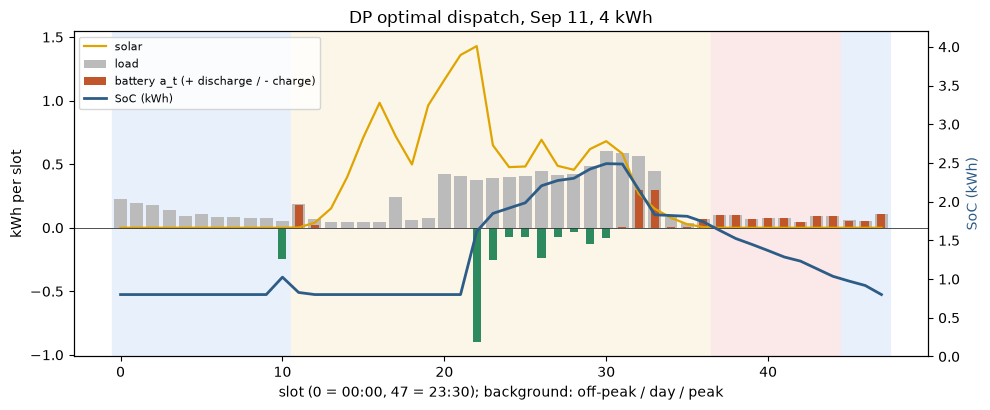

remaining grid cost by band:
Day          0.23
Off-Peak    51.60
Peak         0.56


In [4]:
day = model.get_day(df, "2026-09-11")
cap = 4
res = solve_dp(day, cap)
check = model.simulate(res["schedule"], day, cap)
base = model.baseline_bill(day)
print(f"no battery: Rs {base:.2f}   DP optimum: Rs {res['bill']:.2f}   saving {100*(base-res['bill'])/base:.1f}%")
print(f"replay through the shared simulate(): bill Rs {check['bill']:.2f}, violation {check['violation']:.2e}, feasible = {check['feasible']}")
print(f"{res['n_states']} states x {res['n_moves']} moves x 48 slots, solved in {res['runtime_s']:.2f} s")

x = np.arange(48)
fig, ax1 = plt.subplots(figsize=(10, 4.2))
for t0, t1, c in [(0, 11, "#e8f1fb"), (11, 37, "#fbf6e8"), (37, 45, "#fbe8e8"), (45, 48, "#e8f1fb")]:
    ax1.axvspan(t0 - 0.5, t1 - 0.5, color=c, zorder=0)
ax1.bar(x, day["demand"], color="#bbb", width=0.8, label="load")
ax1.plot(x, day["solar"], color="#e0a400", lw=1.6, label="solar")
ax1.bar(x, res["schedule"], color=["#2d8a5f" if a < 0 else "#c0562a" for a in res["schedule"]],
        width=0.5, label="battery a_t (+ discharge / - charge)")
ax1.axhline(0, color="#333", lw=0.6)
ax1.set_xlabel("slot (0 = 00:00, 47 = 23:30); background: off-peak / day / peak")
ax1.set_ylabel("kWh per slot")
ax2 = ax1.twinx()
ax2.plot(x, res["soc"], color="#2d5c86", lw=2, label="SoC (kWh)")
ax2.set_ylabel("SoC (kWh)", color="#2d5c86")
ax2.set_ylim(0, cap * 1.05)
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper left")
ax1.set_title("DP optimal dispatch, Sep 11, 4 kWh")
fig.tight_layout(); fig.savefig(FIGURES / "dp_dispatch_sep11_4kwh.png", dpi=150); plt.show()

grid = model.grid_import(day["demand"], day["solar"], res["schedule"])
print("remaining grid cost by band:")
print(pd.Series(day["price"] * grid).groupby(day["band"]).sum().round(2).to_string())

The battery charges from surplus solar, carries it into the evening and covers the peak. What
the household still pays is mostly the **night/early-morning load before sunrise**: every day starts
at the 20 % floor, so that load cannot be served from the battery whatever its size (see §8).

## 5. Battery efficiency: calibrated from the logs

`scripts/calibrate_eta.py` replays the logged 5-minute `Battery(kW)` through the transition and fits
it to the logged `SOC(%)`. Only the round-trip efficiency and the effective capacity are
identifiable; the round trip is split symmetrically.

In [5]:
print(pd.read_csv(RESULTS / "eta_calibration.csv").round(3).T.to_string(header=False))
print()
print(pd.read_csv(RESULTS / "eta_replay_errors.csv").to_string(index=False))

b1          13.295
b2          15.997
round_trip   0.831
eta          0.912
cap_kWh      6.857
rmse_pct     0.744
n_windows      206
plausible     True

       day      params  end_error_pct  max_abs_error_pct
2026-09-10      fitted           0.53               6.95
2026-09-10 placeholder           3.80               9.97
2026-09-11      fitted           4.94               8.73
2026-09-11 placeholder           6.58              11.54
2026-09-13      fitted           3.70               3.95
2026-09-13 placeholder           8.06               8.29
2026-09-16      fitted           9.18               9.45
2026-09-16 placeholder          10.76              11.01
2026-09-17      fitted           5.26               8.78
2026-09-17 placeholder           6.69              10.94


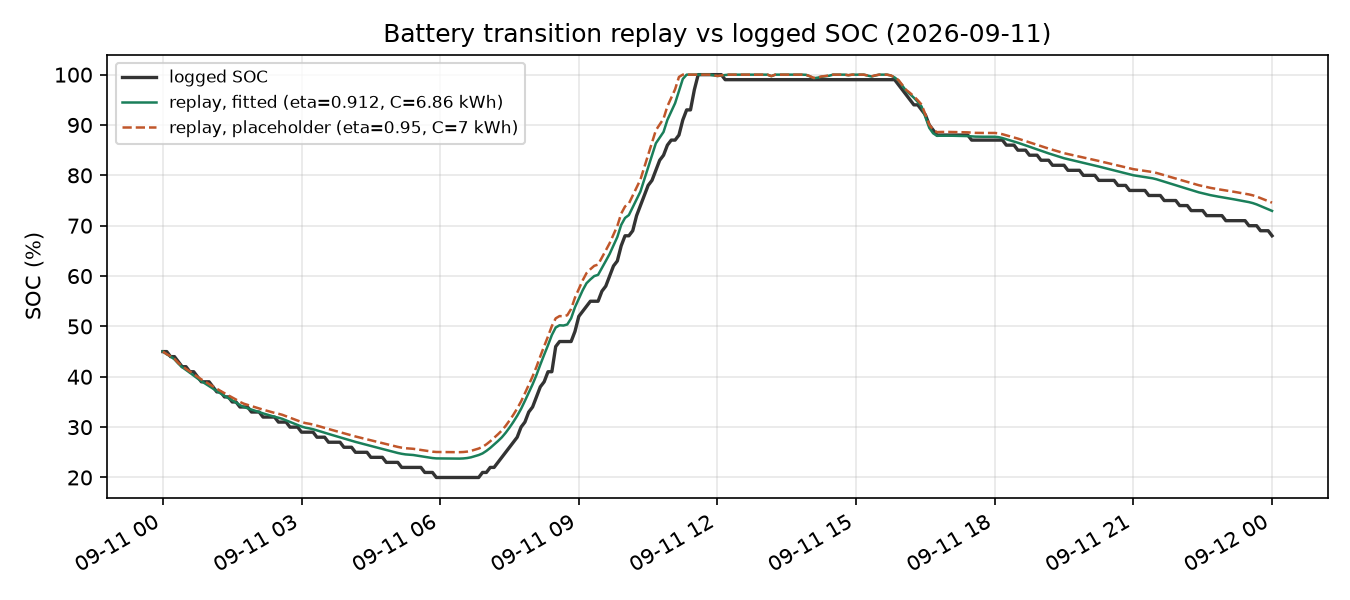

In [6]:
from IPython.display import Image
Image(filename=str(FIGURES / "eta_replay.png"))

The fitted values (eta ~ 0.91, 6.86 kWh, close to the 7 kWh nameplate) track the logged SOC better than
the 0.95 placeholder on every day (end-of-day error 0.5-9 % vs 3.8-11 %), so **eta = 0.91 is used for both solvers**. A standby-drain term could not be
separated from the efficiency (the battery is almost never idle in these logs), so eta absorbs both:
a conservative assumption for the battery's value.

## 6. Discretisation: grid step vs accuracy and runtime

       states  moves  mean_bill  runtime_s
delta                                     
0.100      57     24    115.955      0.007
0.050     113     48     81.384      0.073
0.020     281    119     64.630      0.084
0.010     561    238     59.630      0.076
0.005    1121    475     56.847      0.174
0.002    2801   1187     55.308      0.577
0.001    5601   2375     54.840      1.821


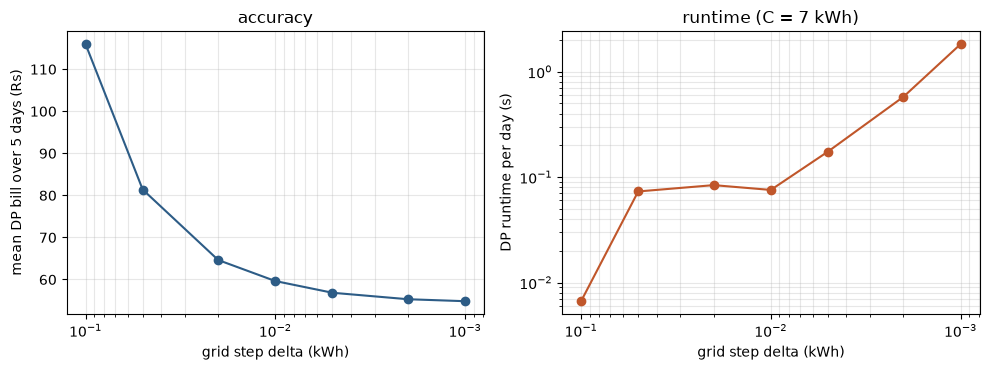

In [7]:
dl = pd.read_csv(RESULTS / "scaling_delta.csv")
g = dl.groupby("delta").agg(states=("n_states", "first"), moves=("n_moves", "first"),
                            mean_bill=("dp_bill", "mean"), runtime_s=("runtime_med_s", "mean")).sort_index(ascending=False)
print(g.round(3).to_string())

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.8))
a1.plot(g.index, g["mean_bill"], "o-", color="#2d5c86"); a1.set_xscale("log"); a1.invert_xaxis()
a1.set_xlabel("grid step delta (kWh)"); a1.set_ylabel("mean DP bill over 5 days (Rs)"); a1.set_title("accuracy")
a2.loglog(g.index, g["runtime_s"], "o-", color="#c0562a"); a2.invert_xaxis()
a2.set_xlabel("grid step delta (kWh)"); a2.set_ylabel("DP runtime per day (s)"); a2.set_title("runtime (C = 7 kWh)")
for a in (a1, a2): a.grid(alpha=0.3, which="both")
fig.tight_layout(); fig.savefig(FIGURES / "dp_delta_scaling.png", dpi=150); plt.show()

States grow as $1/\delta$ and moves per state as $1/\delta$, so DP work grows as $1/\delta^2$. The bill
converges roughly linearly in $\delta$: one partial step of load per slot cannot be matched
exactly. $\delta$ = 0.001 kWh is used for the results (about 1 % above the extrapolated continuous optimum).

## 7. DP vs GA: quality, feasibility, runtime (5 days x 4 capacities)

In [8]:
sw = pd.read_csv(RESULTS / "sweep_summary.csv")
cols = ["date", "capacity", "baseline", "greedy", "dp_bill", "ga_best", "ga_mean", "ga_worst",
        "ga_feasible_rate", "ga_gap_mean_pct", "dp_runtime_med_s", "ga_runtime_med_s", "dp_feasible"]
print(sw[cols].round(2).to_string(index=False))
print("\nAll DP schedules feasible on replay:", bool(sw["dp_feasible"].all()))

      date  capacity  baseline  greedy  dp_bill  ga_best  ga_mean  ga_worst  ga_feasible_rate  ga_gap_mean_pct  dp_runtime_med_s  ga_runtime_med_s  dp_feasible
2026-09-10         0    338.67  338.67   338.67   338.67   338.67    338.67               1.0            -0.00              0.00              1.35         True
2026-09-10         2    338.67  184.33   179.31   184.33   184.33    184.33               1.0             2.80              0.87              1.39         True
2026-09-10         4    338.67  133.87    85.79   103.29   105.21    107.77               1.0            22.64              2.07              1.92         True
2026-09-10         7    338.67  133.87    75.76    80.27    82.87     86.25               1.0             9.38              3.05              2.29         True
2026-09-11         0    160.91  160.91   160.91   160.91   160.91    160.91               1.0             0.00              0.00              1.74         True
2026-09-11         2    160.91   92.54  

          baseline  greedy      dp  ga_mean  ga_best  ga_gap_mean_pct  ga_feasible  dp_s  ga_s  ga_gens_to_1pct  dp_saving_pct
capacity                                                                                                                      
0           196.66  196.66  196.66   196.66   196.66            -0.00          1.0  0.00  1.47              1.0           0.00
2           196.66  103.40   76.80    89.27    84.93            23.57          1.0  0.87  1.36              NaN          60.95
4           196.66   93.31   56.85    66.47    63.39            16.63          1.0  1.45  1.57              NaN          71.09
7           196.66   93.31   54.84    62.20    59.39            14.78          1.0  2.16  1.55              NaN          72.11


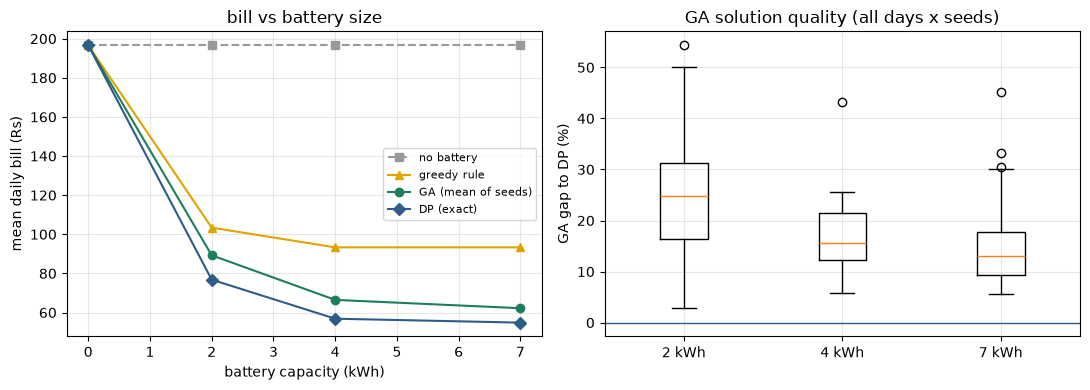

In [9]:
by_c = sw.groupby("capacity").agg(baseline=("baseline", "mean"), greedy=("greedy", "mean"),
                                  dp=("dp_bill", "mean"), ga_mean=("ga_mean", "mean"), ga_best=("ga_best", "mean"),
                                  ga_gap_mean_pct=("ga_gap_mean_pct", "mean"), ga_feasible=("ga_feasible_rate", "mean"),
                                  dp_s=("dp_runtime_med_s", "mean"), ga_s=("ga_runtime_med_s", "mean"),
                                  ga_gens_to_1pct=("ga_gens_to_1pct_med", "median"))
by_c["dp_saving_pct"] = 100 * (by_c["baseline"] - by_c["dp"]) / by_c["baseline"]
print(by_c.round(2).to_string())

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(by_c.index, by_c["baseline"], "s--", color="#999", label="no battery")
a1.plot(by_c.index, by_c["greedy"], "^-", color="#e0a400", label="greedy rule")
a1.plot(by_c.index, by_c["ga_mean"], "o-", color="#1a7f5a", label="GA (mean of seeds)")
a1.plot(by_c.index, by_c["dp"], "D-", color="#2d5c86", label="DP (exact)")
a1.set_xlabel("battery capacity (kWh)"); a1.set_ylabel("mean daily bill (Rs)"); a1.legend(fontsize=8)
a1.set_title("bill vs battery size"); a1.grid(alpha=0.3)
runs = pd.read_csv(RESULTS / "sweep_ga_runs.csv")
runs = runs[runs["capacity"] > 0]
data = [runs[runs["capacity"] == c]["gap_pct"] for c in sorted(runs["capacity"].unique())]
a2.boxplot(data, tick_labels=[f"{c:g} kWh" for c in sorted(runs["capacity"].unique())])
a2.axhline(0, color="#2d5c86", lw=1)
a2.set_ylabel("GA gap to DP (%)"); a2.set_title("GA solution quality (all days x seeds)"); a2.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(FIGURES / "dp_vs_ga_quality.png", dpi=150); plt.show()

## 8. Scalability in the horizon: 1, 2 and 5 chained days (C = 7 kWh)

 horizon_days  slots  baseline  dp_bill  dp_independent_days_bill  ga_best  ga_mean  ga_feasible_rate  ga_gap_mean_pct  dp_runtime_med_s  ga_runtime_med_s
            1     48    338.67    75.76                     75.76    80.27    82.87               1.0             9.38              1.90              1.32
            2     96    499.58    76.77                    128.15   144.11   167.29               1.0           117.89              3.80              2.32
            5    240    983.31    79.02                    274.20   442.48   463.35               1.0           486.39              9.76              4.69


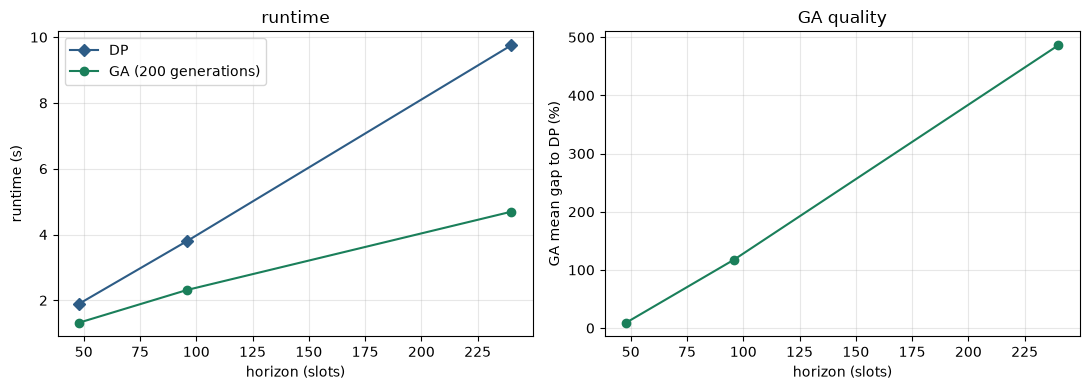

In [10]:
hz = pd.read_csv(RESULTS / "scaling_horizon.csv")
print(hz[["horizon_days", "slots", "baseline", "dp_bill", "dp_independent_days_bill", "ga_best", "ga_mean",
          "ga_feasible_rate", "ga_gap_mean_pct", "dp_runtime_med_s", "ga_runtime_med_s"]].round(2).to_string(index=False))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(hz["slots"], hz["dp_runtime_med_s"], "D-", color="#2d5c86", label="DP")
a1.plot(hz["slots"], hz["ga_runtime_med_s"], "o-", color="#1a7f5a", label="GA (200 generations)")
a1.set_xlabel("horizon (slots)"); a1.set_ylabel("runtime (s)"); a1.legend(); a1.grid(alpha=0.3); a1.set_title("runtime")
a2.plot(hz["slots"], hz["ga_gap_mean_pct"], "o-", color="#1a7f5a")
a2.set_xlabel("horizon (slots)"); a2.set_ylabel("GA mean gap to DP (%)"); a2.grid(alpha=0.3); a2.set_title("GA quality")
fig.tight_layout(); fig.savefig(FIGURES / "horizon_scaling.png", dpi=150); plt.show()

## 9. Sensitivity to the battery efficiency

In [11]:
es = pd.read_csv(RESULTS / "eta_sensitivity.csv")
print(es.pivot_table(index="capacity", columns="eta", values="saving_pct", aggfunc="mean").round(1).to_string())

eta       0.91  0.95  1.00
capacity                  
2         64.2  65.6  67.2
4         70.5  71.3  72.4
7         71.1  71.6  72.4


## 10. Findings

Numbers are means over the 5 real days unless stated (Δ = 0.001 kWh, η = 0.91, 10 GA seeds).

1. **The DP is exact and fast enough.** Every DP schedule replays through the shared `simulate()`
   as feasible and at the cost the DP reports. No GA run in 200 (20 scenarios × 10 seeds) beat it.
   A day solves in about 0.9–2.2 s (2,801–5,601 states × 2,375 moves × 48 slots).
2. **Optimised dispatch matters, and much of the value comes early.** The DP cuts the mean daily bill
   from Rs 196.7 (no battery) to Rs 76.8 / 56.9 / 54.8 for 2 / 4 / 7 kWh (61 / 71 / 72 % saving).
   Beyond ~4 kWh the battery is rarely the bottleneck. The simple greedy rule leaves a lot on the table
   (Rs 103 / 93 / 93).
3. **The GA is always feasible but not optimal.** With per-slot bounds clipped and SoC limits
   penalised, 100 % of runs end feasible. The mean gap to the DP is 24 % / 17 % / 15 % (2 / 4 / 7 kWh),
   and its best seed is still about 5–20 % above. With its default budget (pop 100 × 200
   generations, ~1.5 s, about the same as the DP) it never got within 1 % of the optimum.
4. **Discretisation is the DP's main trade-off.** The DP's work grows as 1/δ², while the bill error
   shrinks roughly linearly in δ: Rs 59.6 at δ = 0.01 vs 54.8 at δ = 0.001 (0.08 s vs 1.8 s per day).
   A coarse grid gives a *wrong* optimum quickly, not an approximate one.
5. **Horizon scalability.** Chaining 1 → 2 → 5 days (48 → 240 slots) grows the DP's runtime
   linearly (1.9 → 9.8 s) and keeps it exact. The GA's search space grows exponentially, and with a
   fixed budget its gap explodes (9 % → 118 % → 486 %).
6. **The 'start each day at the floor' assumption is expensive.** Optimised over 5 chained days the
   7 kWh battery costs Rs 79 in total, versus Rs 274 when each day is optimised independently from
   the floor. Carrying charge overnight covers the pre-dawn load, which is the main residual cost in
   the daily model. Multi-day (or receding-horizon) operation is the main future-work direction.
7. **Efficiency.** The logs give a round trip of about 0.83 (η = 0.91). Savings are fairly insensitive
   to it: 2–3 points between η = 0.91 and lossless.
